In [1]:
import geopandas as gpd
import rioxarray as rio
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

In [2]:
gland = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Greenland Boundary\coast.shp").to_crs(epsg=4326)
temp = rio.open_rasterio(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\cru_ts4.09.1901.2024.tmp.dat.nc\cru_ts4.09.1901.2024.tmp.dat.nc")
prcp = rio.open_rasterio(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\cru_ts4.09.1901.2024.pre.dat.nc\cru_ts4.09.1901.2024.pre.dat.nc")

sland = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Scotland Outline\scotland.shp").to_crs(epsg=27700)
s_temp = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Climate\Monthly_Temperature_Observations_1991_2020_5162185003707910731\Monthly_Temperature_Observations_1991-2020.shp").to_crs(epsg=27700)
s_prcp = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Climate\Monthly_Precipitation_Observations_1991_2020_6437788962260621308\Monthly_Precipitation_Observations_1991-2020.shp").to_crs(epsg=27700)

    

In [3]:
# Assign the greenland shapefile CRS to climate data

temp.rio.write_crs(gland.crs, inplace=True)
prcp.rio.write_crs(gland.crs, inplace=True)

# Clip climate data to Greenland boundary

tclipped = temp.rio.clip(gland.geometry.values, drop=True)
tclean = tclipped.where(tclipped != tclipped.tmp.rio.nodata)

pclipped = prcp.rio.clip(gland.geometry.values, drop=True)
pclean = pclipped.where(pclipped != pclipped.pre.rio.nodata)

# Select data for the period 1991-2020

t91_20 = tclean.sel(time=slice('1991-01-01', '2020-12-31'))
p91_20 = pclean.sel(time=slice('1991-01-01', '2020-12-31'))

# Resample to annual data

annualtmp = t91_20.resample(time='1YE').mean()
annualprcp = p91_20.resample(time='1YE').sum()

# Calculate mean annual temperature and total annual precipitation

gtemp = annualtmp['tmp'].mean(dim='time')
gprcp = annualprcp['pre'].mean(dim='time')

# Reproject to EPSG:3413

gtemp = gtemp.rio.reproject("EPSG:3413")
gprcp = gprcp.rio.reproject("EPSG:3413")
gprcp = gprcp.where(gprcp > 0)  # Remove zero values for precipitation

# Save to GeoTIFF

gtemp.rio.to_raster(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\temp.tif")
gprcp.rio.to_raster(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\prcp.tif")

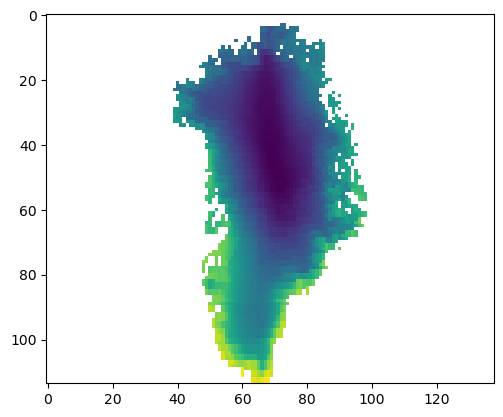

In [4]:
import rasterio as rio
from matplotlib import pyplot as plt

data = rio.open(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\temp.tif")

plt.imshow(data.read(1), cmap='viridis')

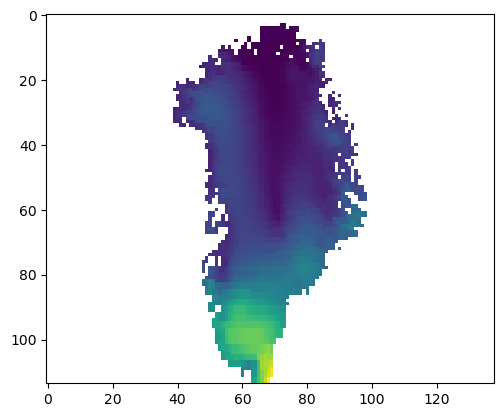

In [5]:
tinga = rio.open(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Climate\prcp.tif")


plt.imshow(tinga.read(1), cmap='viridis')



In [6]:
#clip the UK datasets to the Scotland boundary

stemp = s_temp.clip(sland)
sprcp = s_prcp.clip(sland)

In [7]:
#Calculate mean temperature and total precipitation for each grid cell

stemp_values = stemp.select_dtypes(include=['float64', 'int64']).columns

stemp['mean'] = stemp[stemp_values].mean(axis=1)

sprcp_values = sprcp.select_dtypes(include=['float64', 'int64']).columns

sprcp['total'] = sprcp[sprcp_values].sum(axis=1)


In [8]:
sprcp.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Climate\prcp.shp")

stemp.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Climate\temp.shp")

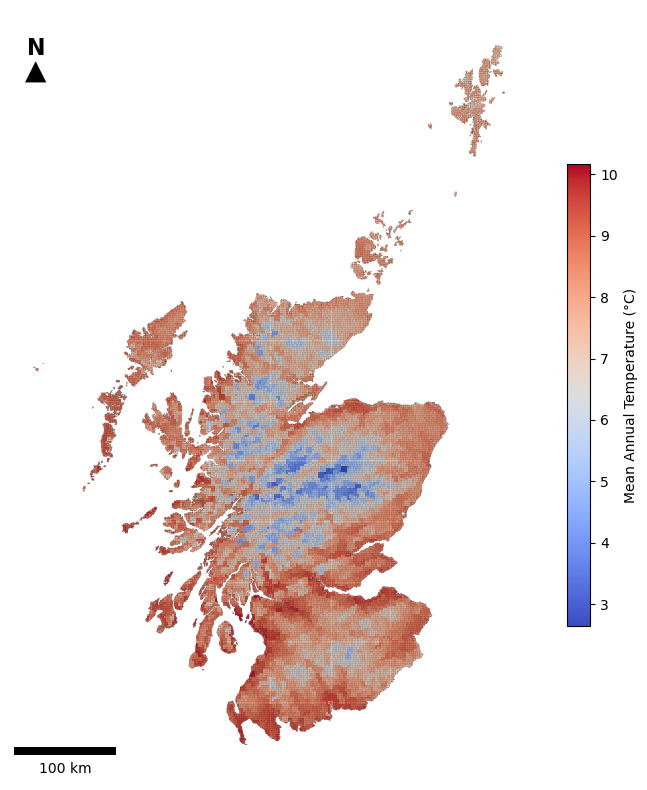

In [9]:
# Define colormap and norm
cmap = plt.cm.coolwarm
norm = mcolors.Normalize(vmin=stemp['mean'].min(), vmax=stemp['mean'].max())

fig, ax = plt.subplots(figsize=(10, 10))

# Plot using the same cmap and norm
stemp.plot(ax=ax, column='mean', cmap=cmap, norm=norm, edgecolor='black',
           linewidth=0.1, legend=False)

# Add shrunk colorbar manually
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                    ax=ax, label="Mean Annual Temperature (°C)", shrink=0.6)

ax.add_artist(ScaleBar(1, location="lower left")) 

ax.annotate("N", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=16, 
            ha="center", va="center", fontweight="bold", color="black")
ax.annotate("▲", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=20, 
            ha="center", va="center", fontweight="bold", color="black")

ax.set_axis_off()

fig.savefig(r"D:\OneDrive - Loughborough University\Project\Results\Figures\Scotland\Temp.png", dpi=600, bbox_inches='tight')


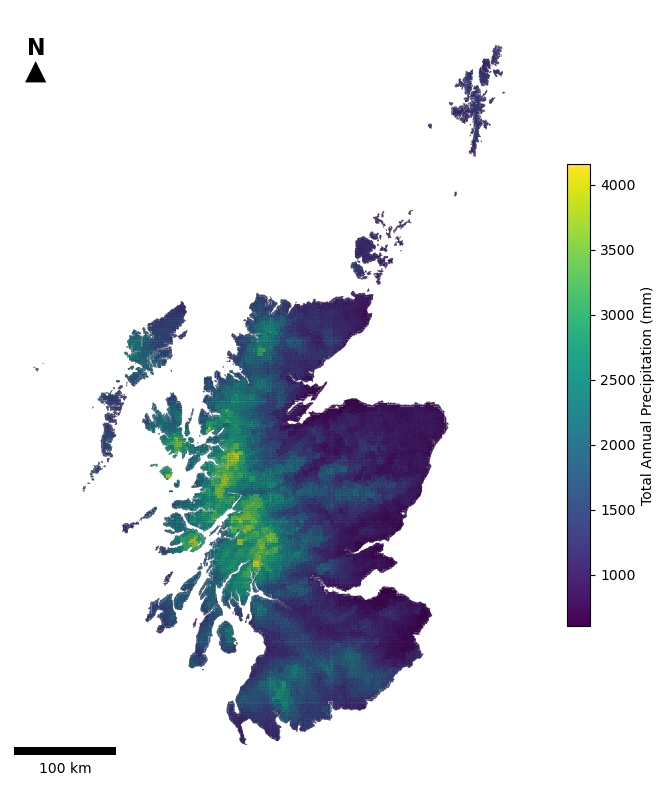

In [10]:
# Define colormap and norm
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=sprcp['total'].min(), vmax=sprcp['total'].max())

fig, ax = plt.subplots(figsize=(10, 10))

# Plot using the same cmap and norm
sprcp.plot(ax=ax, column='total', cmap=cmap, norm=norm, edgecolor='black',
           linewidth=0.1, legend=False)

# Add shrunk colorbar manually
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                    ax=ax, label="Total Annual Precipitation (mm)", shrink=0.6)

ax.add_artist(ScaleBar(1, location="lower left")) 

ax.annotate("N", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=16, 
            ha="center", va="center", fontweight="bold", color="black")
ax.annotate("▲", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=20, 
            ha="center", va="center", fontweight="bold", color="black")

ax.set_axis_off()

fig.savefig(r"D:\OneDrive - Loughborough University\Project\Results\Figures\Scotland\Prcp.png", dpi=600, bbox_inches='tight')


In [11]:
#Calculate mean temperature and total precipitation for each grid cell

s_temp_values = s_temp.select_dtypes(include=['float64', 'int64']).columns

s_temp['mean'] = s_temp[s_temp_values].mean(axis=1)

s_prcp_values = s_prcp.select_dtypes(include=['float64', 'int64']).columns

s_prcp['total'] = s_prcp[s_prcp_values].sum(axis=1)

In [12]:
def convert_to_raster(gdf, value, fn):
    gdf = gdf
    value_column = value

    # Grab one cell to infer dimensions
    sample_bounds = gdf.geometry.iloc[598].bounds
    cell_width = sample_bounds[2] - sample_bounds[0]
    cell_height = sample_bounds[3] - sample_bounds[1]

    # Compute grid origin and shape based on actual geometries
    minx, miny, maxx, maxy = gdf.total_bounds
    ncols = int(round((maxx - minx) / cell_width))
    nrows = int(round((maxy - miny) / cell_height))

    # Use top-left corner as origin (rasterio expects upper-left)
    transform = from_origin(minx, maxy, cell_width, cell_height)

    shapes = [(geom, val) for geom, val in zip(gdf.geometry, gdf[value_column])]

    raster = rasterize(
        shapes,
        out_shape=(nrows, ncols),
        transform=transform,
        fill=np.nan,
        dtype="float32"
    )

    with rasterio.open(
        fr"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Climate\{fn}.tif", "w",
        driver="GTiff",
        height=nrows,
        width=ncols,
        count=1,  # single-band raster
        dtype="float32",  # or match `raster.dtype` if dynamic
        transform=transform,
        crs=gdf.crs  # ensure it matches your shapefile
    ) as dst:
        dst.write(raster, 1)

convert_to_raster(s_temp, 'mean', 'temp')
convert_to_raster(s_prcp, 'total', 'prcp')

Text(0, 0.5, '')

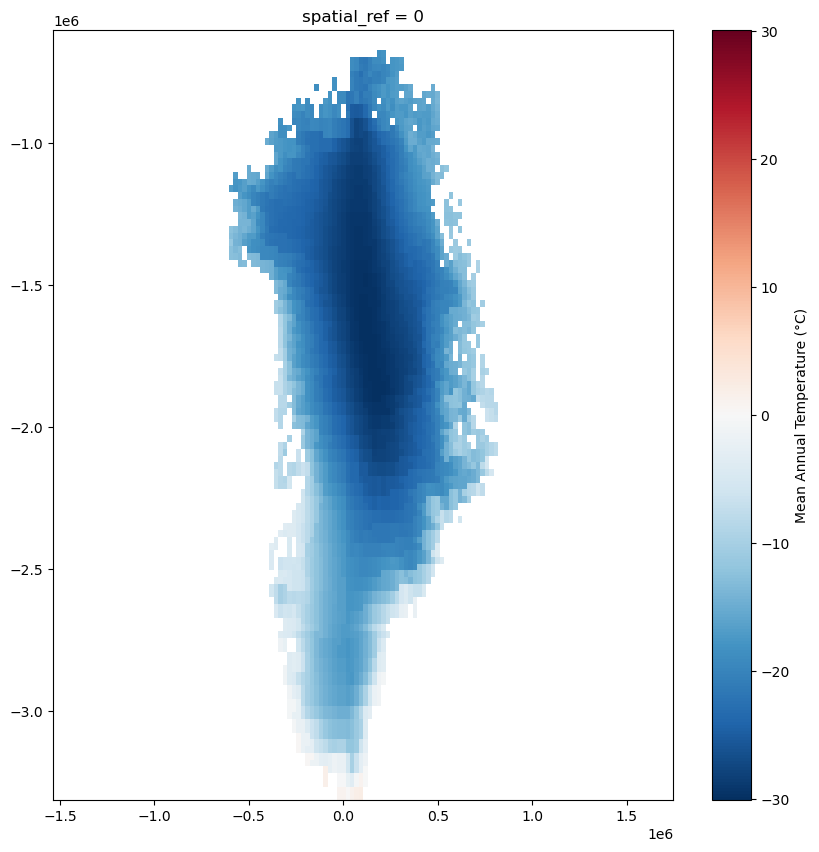

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

gtemp.plot(ax=ax, cbar_kwargs={'label': "Mean Annual Temperature (°C)"})

ax.set_xlabel('')
ax.set_ylabel('')



Text(0, 0.5, '')

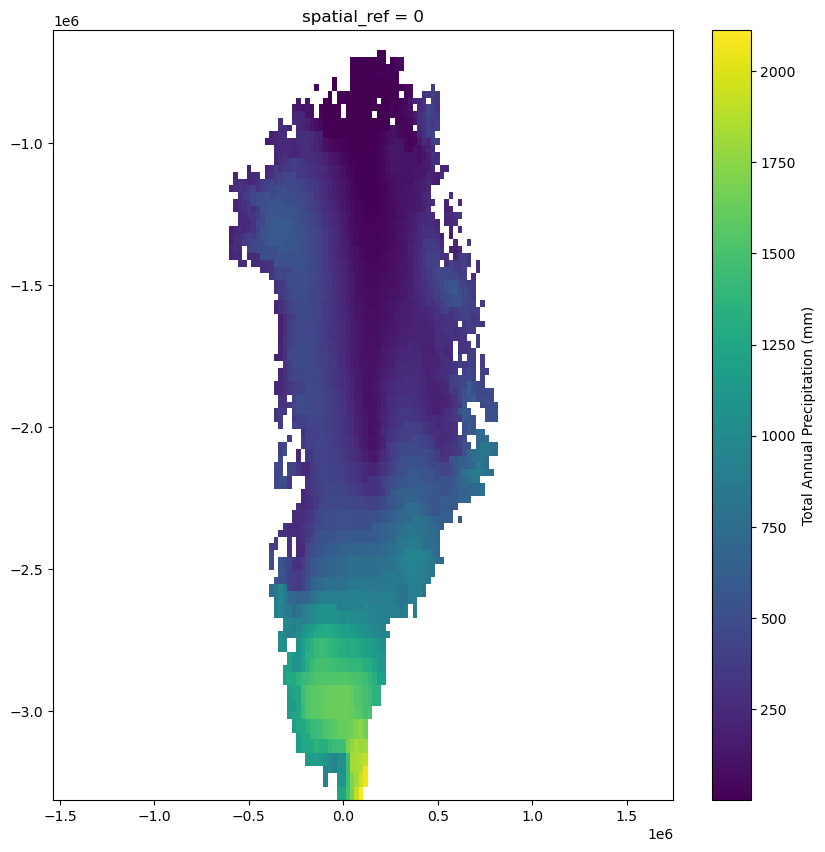

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

gprcp.plot(ax=ax, cbar_kwargs={'label': "Total Annual Precipitation (mm)"})

ax.set_xlabel('')
ax.set_ylabel('')


In [15]:
fn = 'temp'

print(f'processing {fn} data')

processing temp data
